# Exploratory Data Analysis (EDA)

Exploratory analysis of the labeled YouTube and Reddit datasets for the
Israel-Hamas discourse study. This notebook profiles data quality, the stance
(label) distribution, comment length, engagement, and temporal/platform
structure.

**Stance labels:** `P` = Pro-Palestine, `I` = Pro-Israel, `N` = Neutral.

> Data cleaning / type conversion is documented in `data_preprocessing.ipynb`.
> This notebook is read-only: it loads `data/*_labeled.csv` and displays results.

## 1. Setup and Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Visualization defaults
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# Consistent stance naming/colors across the whole project
STANCE_ORDER = ["P", "I", "N"]
STANCE_NAMES = {"P": "Pro-Palestine", "I": "Pro-Israel", "N": "Neutral"}
STANCE_COLORS = {"P": "#2ecc71", "I": "#3498db", "N": "#95a5a6"}


def find_repo_root():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "data" / "reddit_labeled.csv").exists():
            return candidate
    return here


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data"
print("Libraries imported successfully")
print(f"Data dir: {DATA_DIR}")

Libraries imported successfully
Data dir: C:\Users\nitro 5\Desktop\Projects\israel_hamas_discourse_analysis\data


## 2. Load Labeled Data

In [2]:
print("Loading labeled data...")
reddit_df = pd.read_csv(DATA_DIR / "reddit_labeled.csv")
youtube_df = pd.read_csv(DATA_DIR / "youtube_labeled.csv")

# Parse timestamps once here so downstream cells can rely on datetime dtypes.
reddit_df["created_time"] = pd.to_datetime(reddit_df["created_time"], errors="coerce")
youtube_df["created_time"] = pd.to_datetime(youtube_df["created_time"], errors="coerce")

# Derived text-length features (word counts) used in the length analysis.
reddit_df["word_count"] = reddit_df["self_text"].fillna("").str.split().str.len()
youtube_df["word_count"] = youtube_df["text"].fillna("").str.split().str.len()

print(f"Reddit data : {len(reddit_df):,} rows x {reddit_df.shape[1]} columns")
print(f"YouTube data: {len(youtube_df):,} rows x {youtube_df.shape[1]} columns")
print(f"Total       : {len(reddit_df) + len(youtube_df):,} comments")

Loading labeled data...
Reddit data : 1,110,153 rows x 19 columns
YouTube data: 378,267 rows x 11 columns
Total       : 1,488,420 comments


## 3. Dataset Overview

In [3]:
print("=" * 60)
print("REDDIT DATASET OVERVIEW")
print("=" * 60)
print(f"\nShape: {reddit_df.shape}")
print(f"\nColumns: {list(reddit_df.columns)}")
print(f"\nData Types:")
print(reddit_df.dtypes)
print(f"\nMissing Values (top columns):")
print(reddit_df.isnull().sum()[lambda s: s > 0].sort_values(ascending=False).head(10))

REDDIT DATASET OVERVIEW

Shape: (1110153, 19)

Columns: ['index', 'Label', 'Reasoning', 'self_text', 'comment_id', 'score', 'author_name', 'controversiality', 'created_time', 'subreddit', 'post_id', 'parent_id', 'permalink', 'post_title', 'post_score', 'post_upvote_ratio', 'post_created_time', 'num_comments', 'word_count']

Data Types:
index                         int64
Label                           str
Reasoning                       str
self_text                       str
comment_id                      str
score                         int64
author_name                     str
controversiality              int64
created_time         datetime64[us]
subreddit                       str
post_id                         str
parent_id                       str
permalink                       str
post_title                      str
post_score                    int64
post_upvote_ratio           float64
post_created_time               str
num_comments                  int64
word_count    

In [4]:
print("=" * 60)
print("YOUTUBE DATASET OVERVIEW")
print("=" * 60)
print(f"\nShape: {youtube_df.shape}")
print(f"\nColumns: {list(youtube_df.columns)}")
print(f"\nData Types:")
print(youtube_df.dtypes)
print(f"\nMissing Values (top columns):")
print(youtube_df.isnull().sum()[lambda s: s > 0].sort_values(ascending=False).head(10))

YOUTUBE DATASET OVERVIEW

Shape: (378267, 11)

Columns: ['index', 'Label', 'Reasoning', 'id', 'video id', 'author', 'text', 'likeCount', 'created_time', 'video_date', 'word_count']

Data Types:
index                    int64
Label                      str
Reasoning                  str
id                         str
video id                   str
author                     str
text                       str
likeCount              float64
created_time    datetime64[us]
video_date                 str
word_count               int64
dtype: object

Missing Values (top columns):
Series([], dtype: int64)


## 4. Stance (Label) Distribution

How the three stances are distributed within and across platforms.

Stance distribution by platform:

               Reddit (n)  Reddit (%)  YouTube (n)  YouTube (%)
Pro-Palestine      494608        44.6       212217         56.1
Pro-Israel         370616        33.4       131357         34.7
Neutral            244929        22.1        34693          9.2


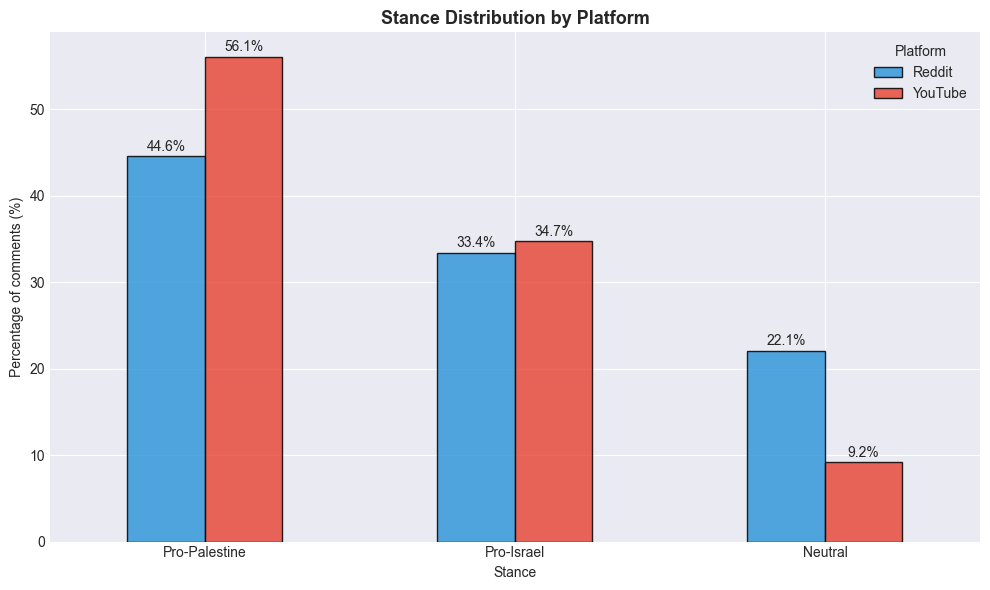

In [5]:
# Build a side-by-side comparison table (counts and percentages)
reddit_counts = reddit_df["Label"].value_counts().reindex(STANCE_ORDER)
youtube_counts = youtube_df["Label"].value_counts().reindex(STANCE_ORDER)

dist = pd.DataFrame({
    "Reddit (n)": reddit_counts,
    "Reddit (%)": (reddit_counts / reddit_counts.sum() * 100).round(1),
    "YouTube (n)": youtube_counts,
    "YouTube (%)": (youtube_counts / youtube_counts.sum() * 100).round(1),
})
dist.index = [STANCE_NAMES[s] for s in dist.index]
print("Stance distribution by platform:\n")
print(dist)

# Grouped bar chart of percentages
fig, ax = plt.subplots(figsize=(10, 6))
pct = pd.DataFrame({
    "Reddit": reddit_counts / reddit_counts.sum() * 100,
    "YouTube": youtube_counts / youtube_counts.sum() * 100,
})
pct.index = [STANCE_NAMES[s] for s in pct.index]
pct.plot(kind="bar", ax=ax, color=["#3498db", "#e74c3c"], edgecolor="black", alpha=0.85)
ax.set_title("Stance Distribution by Platform", fontsize=13, fontweight="bold")
ax.set_xlabel("Stance")
ax.set_ylabel("Percentage of comments (%)")
ax.legend(title="Platform")
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=2)
plt.tight_layout()
plt.show()

## 5. Comment Length Analysis

Comment length (in words) is a basic proxy for how much elaboration each platform
invites, and feeds into the narrative-complexity analysis in module 04.

Comment length (words) summary:

          Reddit   YouTube
count  1110153.0  378267.0
mean        50.6      18.4
std         71.5      33.9
min          1.0       1.0
25%         12.0       5.0
50%         28.0      10.0
75%         62.0      21.0
max       1721.0    1780.0

Median comment length (words) by stance:
  Reddit: Pro-Palestine=29, Pro-Israel=36, Neutral=18
  YouTube: Pro-Palestine=10, Pro-Israel=11, Neutral=9


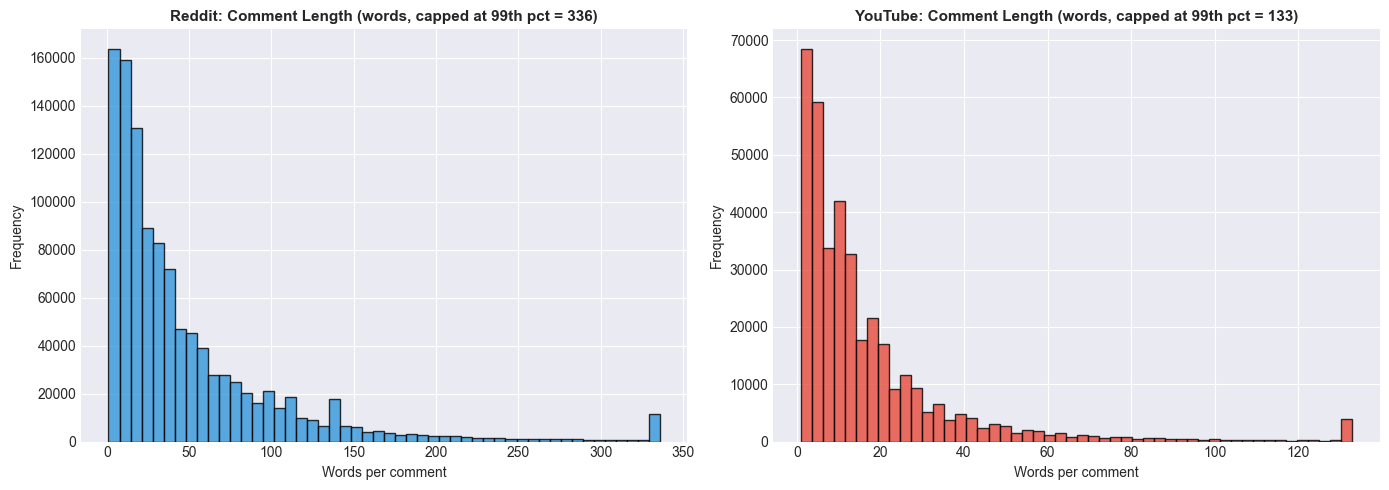

In [6]:
# Length summary by platform
length_summary = pd.DataFrame({
    "Reddit": reddit_df["word_count"].describe(),
    "YouTube": youtube_df["word_count"].describe(),
}).round(1)
print("Comment length (words) summary:\n")
print(length_summary)

# Median length by stance
print("\nMedian comment length (words) by stance:")
for name, df in [("Reddit", reddit_df), ("YouTube", youtube_df)]:
    med = df.groupby("Label")["word_count"].median().reindex(STANCE_ORDER)
    print(f"  {name}: " + ", ".join(f"{STANCE_NAMES[s]}={med[s]:.0f}" for s in STANCE_ORDER))

# Distribution (clipped at the 99th percentile so long-tail outliers do not hide the bulk)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title, color in [
    (axes[0], reddit_df, "Reddit", "#3498db"),
    (axes[1], youtube_df, "YouTube", "#e74c3c"),
]:
    cap = df["word_count"].quantile(0.99)
    ax.hist(df["word_count"].clip(upper=cap), bins=50, color=color,
            edgecolor="black", alpha=0.8)
    ax.set_title(f"{title}: Comment Length (words, capped at 99th pct = {cap:.0f})",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Words per comment")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

## 6. Engagement Metrics

Reddit Engagement Statistics:

Comment score:
count    1.110153e+06
mean     9.049732e+00
std      3.254586e+01
min     -3.130000e+02
25%      1.000000e+00
50%      2.000000e+00
75%      7.000000e+00
max      2.239000e+03
Name: score, dtype: float64

Post score:
count    1.110153e+06
mean     3.678232e+02
std      6.614320e+02
min      0.000000e+00
25%      2.300000e+01
50%      1.260000e+02
75%      3.940000e+02
max      7.770000e+03
Name: post_score, dtype: float64


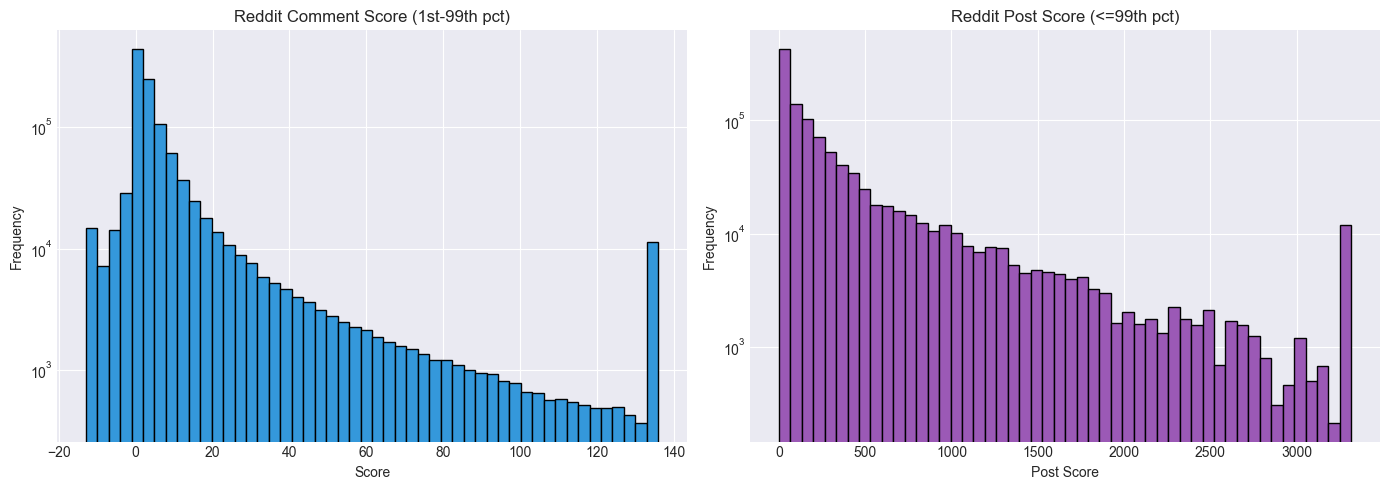

In [7]:
# Reddit engagement (scores are heavy-tailed -> log-scale the frequency axis)
print("Reddit Engagement Statistics:")
print("\nComment score:")
print(reddit_df["score"].describe())
print("\nPost score:")
print(reddit_df["post_score"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
reddit_df["score"].clip(lower=reddit_df["score"].quantile(0.01),
                        upper=reddit_df["score"].quantile(0.99)).hist(
    bins=50, ax=axes[0], edgecolor="black", color="#3498db")
axes[0].set_title("Reddit Comment Score (1st-99th pct)")
axes[0].set_xlabel("Score"); axes[0].set_ylabel("Frequency"); axes[0].set_yscale("log")

reddit_df["post_score"].clip(upper=reddit_df["post_score"].quantile(0.99)).hist(
    bins=50, ax=axes[1], edgecolor="black", color="#9b59b6")
axes[1].set_title("Reddit Post Score (<=99th pct)")
axes[1].set_xlabel("Post Score"); axes[1].set_ylabel("Frequency"); axes[1].set_yscale("log")
plt.tight_layout()
plt.show()

YouTube Like Count Statistics:
count    378267.000000
mean         21.713940
std         337.696099
min           0.000000
25%           0.000000
50%           0.000000
75%           3.000000
max       88000.000000
Name: likeCount, dtype: float64

Comments with 0 likes: 50.4%


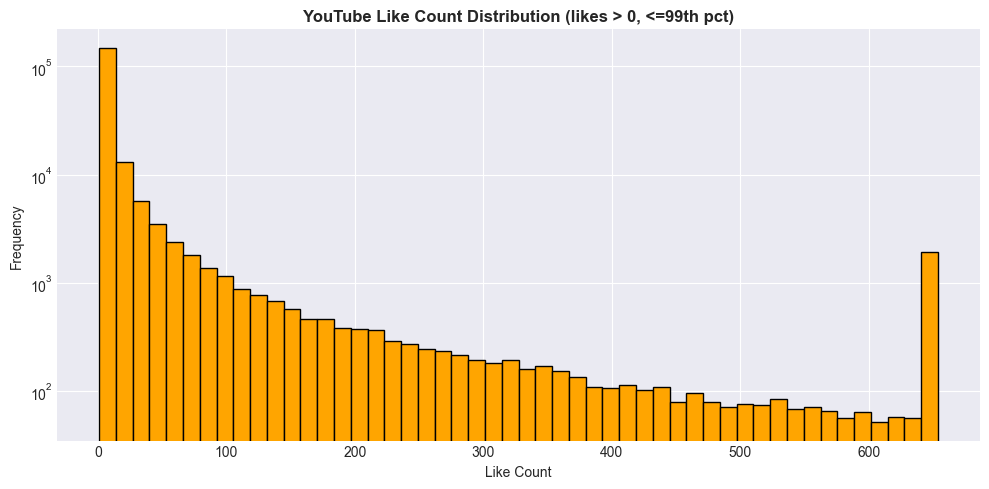

In [8]:
# YouTube engagement
print("YouTube Like Count Statistics:")
print(youtube_df["likeCount"].describe())
print(f"\nComments with 0 likes: {(youtube_df['likeCount'] == 0).mean() * 100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 5))
liked = youtube_df[youtube_df["likeCount"] > 0]["likeCount"]
liked.clip(upper=liked.quantile(0.99)).hist(bins=50, ax=ax, edgecolor="black", color="orange")
ax.set_title("YouTube Like Count Distribution (likes > 0, <=99th pct)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Like Count"); ax.set_ylabel("Frequency"); ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 7. Temporal Analysis

Study window: **Oct 2023 - May 2024**. Reddit is plotted by **comment date**
(`created_time`, the real posting time). YouTube is plotted by **video publish
date** (`video_date`): YouTube's `created_time` is the *scrape/fetch* date (a
relative-"x months ago" artifact that runs into 2025-2026), so it is **not** a
valid comment timeline and `video_date` is used as the temporal anchor instead.

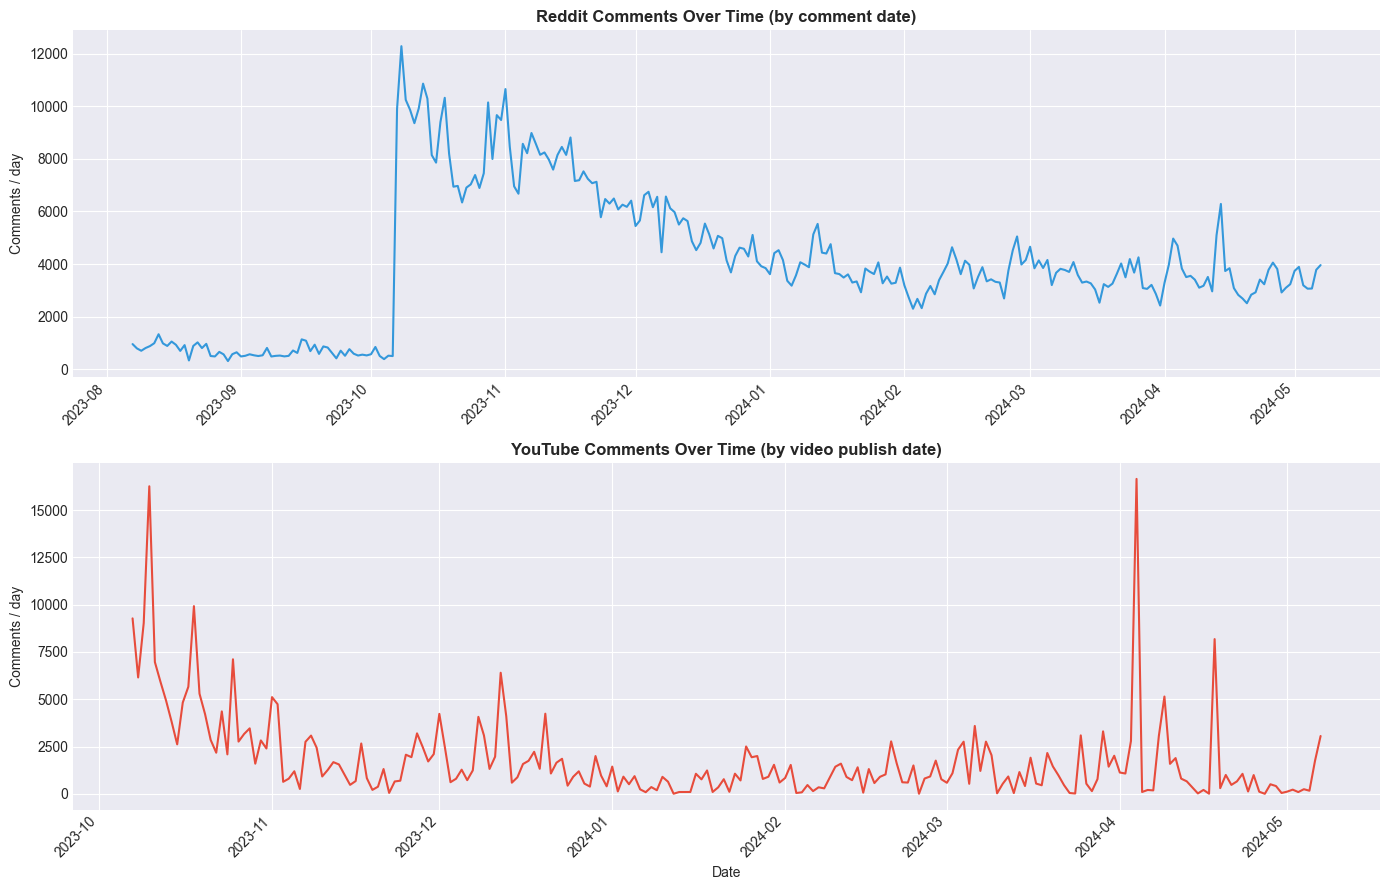

Reddit  comment-date range : 2023-08-07 00:50:40  ->  2024-05-07 23:59:16
YouTube video-date range   : 2023-10-07 00:00:00  ->  2024-05-07 00:00:00
NOTE: YouTube 'created_time' is the scrape date and is NOT used as a timeline (2024-02-25 -> 2026-02-24).


In [9]:
# Activity volume over time.
# Reddit -> real comment timestamp (created_time).
# YouTube -> video_date (video publish date); YouTube created_time is the SCRAPE
# date (runs into 2025-2026) and is NOT a reliable comment timeline.
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

reddit_t = pd.to_datetime(reddit_df["created_time"], errors="coerce")
reddit_daily = reddit_t.dt.date.value_counts().sort_index()
axes[0].plot(reddit_daily.index, reddit_daily.values, color="#3498db")
axes[0].set_title("Reddit Comments Over Time (by comment date)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Comments / day")

youtube_vd = pd.to_datetime(youtube_df["video_date"], errors="coerce")
youtube_daily = youtube_vd.dt.date.value_counts().sort_index()
axes[1].plot(youtube_daily.index, youtube_daily.values, color="#e74c3c")
axes[1].set_title("YouTube Comments Over Time (by video publish date)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Comments / day")

for ax in axes:
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

yt_scrape = pd.to_datetime(youtube_df["created_time"], errors="coerce")
print(f"Reddit  comment-date range : {reddit_t.min()}  ->  {reddit_t.max()}")
print(f"YouTube video-date range   : {youtube_vd.min()}  ->  {youtube_vd.max()}")
print(f"NOTE: YouTube 'created_time' is the scrape date and is NOT used as a "
      f"timeline ({yt_scrape.min().date()} -> {yt_scrape.max().date()}).")

## 8. Source / Platform Structure

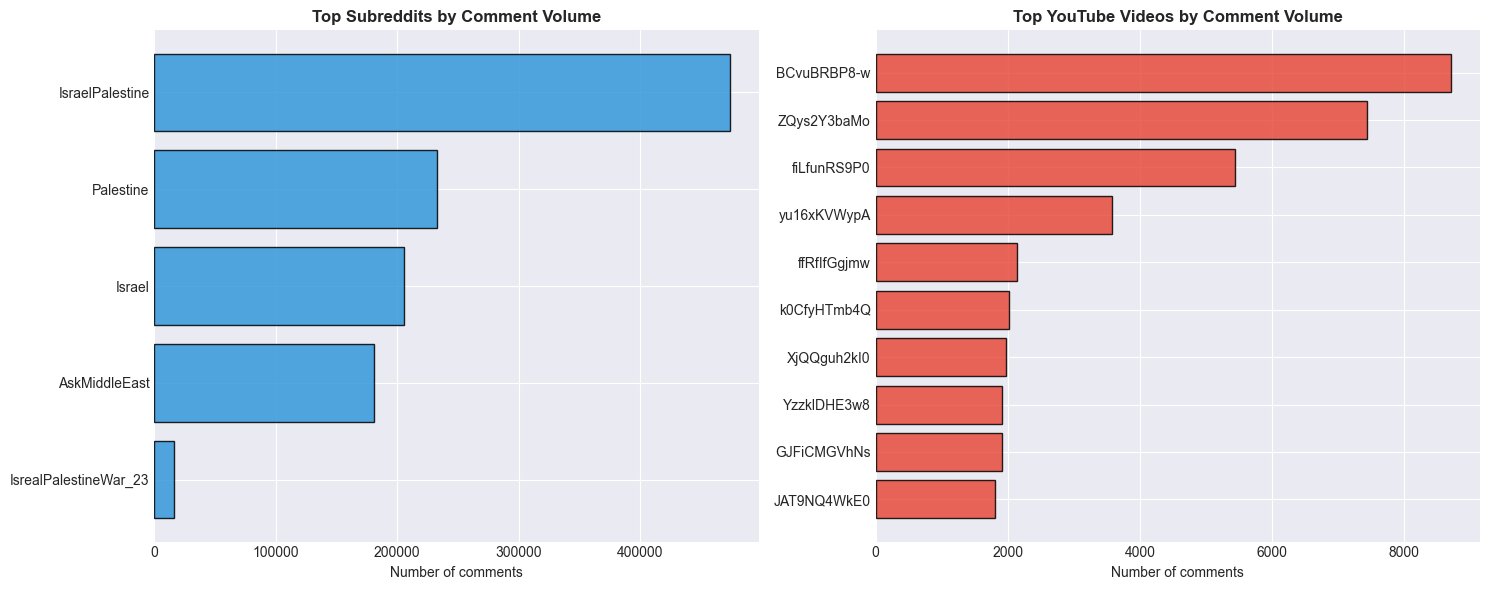

Reddit:  5 subreddits, 104,451 unique authors, 70,471 posts
YouTube: 1,753 videos, 271,478 unique authors


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top subreddits (Reddit)
top_subs = reddit_df["subreddit"].value_counts().head(10)
axes[0].barh(top_subs.index[::-1], top_subs.values[::-1], color="#3498db",
             edgecolor="black", alpha=0.85)
axes[0].set_title("Top Subreddits by Comment Volume", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of comments")

# Top videos (YouTube) by comment volume
top_videos = youtube_df["video id"].value_counts().head(10)
axes[1].barh([str(v) for v in top_videos.index[::-1]], top_videos.values[::-1],
             color="#e74c3c", edgecolor="black", alpha=0.85)
axes[1].set_title("Top YouTube Videos by Comment Volume", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of comments")

plt.tight_layout()
plt.show()

print(f"Reddit:  {reddit_df['subreddit'].nunique()} subreddits, "
      f"{reddit_df['author_name'].nunique():,} unique authors, "
      f"{reddit_df['post_id'].nunique():,} posts")
print(f"YouTube: {youtube_df['video id'].nunique():,} videos, "
      f"{youtube_df['author'].nunique():,} unique authors")

## Summary

This notebook profiled the labeled discourse datasets:

- **Volume & quality** — row/column counts, dtypes and missingness for both platforms.
- **Stance distribution** — share of Pro-Palestine / Pro-Israel / Neutral comments per platform.
- **Comment length** — word-count distributions and medians by stance (feeds module 04).
- **Engagement** — Reddit comment/post scores and YouTube like counts (log-scaled, outlier-capped).
- **Temporal** — activity over the Oct 2023 - May 2024 window: Reddit by comment date, YouTube by **video publish date** (YouTube `created_time` is an unreliable scrape date).
- **Structure** — most active subreddits and videos, plus author/thread counts.

These descriptive baselines frame the four research questions explored in modules 02-05.